In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [3]:
import torch
import numpy as np
import panel as pn
from IPython.display import display, clear_output
pn.extension()

from bokeh.resources import INLINE
import matplotlib.pyplot as plt

# stop on nans
# torch.autograd.set_detect_anomaly(True)

In [4]:
from polarizedpotentialparticles.configs import Config, ParticleConfig, SimulationConfig, LossConfig
from polarizedpotentialparticles.trainer import Trainer
from polarizedpotentialparticles.displays import Displayer
from polarizedpotentialparticles.scripts.generate_dashboard_manifest import build_manifest

In [5]:
p_cfg = ParticleConfig()
t_cfg = SimulationConfig()
l_config = LossConfig()

l_config.target = "thiccdonut"

cfg = Config(particle_config=p_cfg, simulation_config=t_cfg, loss_config=l_config)

trainer = Trainer(cfg)
displayer = Displayer(trainer)

In [6]:
# check if it is running on gpu
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {cfg.device}")

Using device: cuda


# Todo
# ~~State pool~~
# Random Subset update?
# Remember Zero init
Symmetrize

~~N_nbs~~

Normalize different inputs

In [7]:
run_name = "donut_test_split"


import os 
save_dir = os.path.join("../docs/runs", run_name)
os.makedirs(save_dir, exist_ok=True)

In [ ]:
def save(trainer, panel):
    trainer.save_model(os.path.join(save_dir, "model.pt"))
    panel.save(os.path.join(save_dir, "display.html"), resources=INLINE)
    build_manifest()

    
steps = 50

every = int(2000/steps)


d = 10

for ep in range(20000):
    print(ep,"/", "20000", end="\r")
    rnd = np.random.randint(-d, d) if d > 0 else 0
    trainer.train(steps + rnd, accumulate_loss=False, step_loss=True)

    if (ep+1) % 1000 == 0:
        clear_output(wait=True)
        rollout, losses = trainer.rollout_batched(steps = 2*steps)

        panel = displayer.dashboard(rollout, losses)
        display(panel)
        save(trainer, panel)
        # print(rollout[-1][:,2])


BokehModel(combine_events=True, render_bundle={'docs_json': {'6122ec12-ceb4-4aa6-98a2-bd26731059dc': {'version…

Wrote /home/jschauser/PolarizedPotentialParticles/docs/manifest.json
Indexed 14 runs


In [ ]:
rollout[0].shape

(6400, 6)

In [ ]:
trainer.state_pool.states[:]

[tensor([[-6.2737e-01, -3.2638e-01,  6.6375e+00,  3.2288e+01, -2.1072e+01,
          -2.0346e-01],
         [-4.1602e-01, -3.0787e-02,  6.6037e+00,  3.2132e+01, -2.0972e+01,
          -2.0778e-01],
         [ 1.8498e-01, -8.4868e-01,  6.6255e+00,  3.2230e+01, -2.1035e+01,
          -2.0418e-01],
         ...,
         [ 1.6833e-01,  9.9517e-01,  6.5211e+00,  3.1562e+01, -2.0633e+01,
          -1.8013e-01],
         [-6.1895e-01, -1.0536e+00,  6.5427e+00,  3.1665e+01, -2.0698e+01,
          -1.7800e-01],
         [ 7.0976e-01,  3.7411e-01,  6.5316e+00,  3.1707e+01, -2.0713e+01,
          -1.9815e-01]]),
 tensor([[  0.5946,   0.3372,   4.6183,  23.2230, -15.2870,  -0.5115],
         [ -1.0001,  -0.0475,   4.5816,  23.1604, -15.2351,  -0.5378],
         [  0.0566,  -0.1440,   4.6204,  23.2568, -15.3060,  -0.5162],
         ...,
         [  0.8115,   1.0299,   4.5835,  22.8373, -15.0680,  -0.4709],
         [ -1.3636,  -0.8324,   4.6508,  22.8859, -15.1294,  -0.4094],
         [  1.3253,  

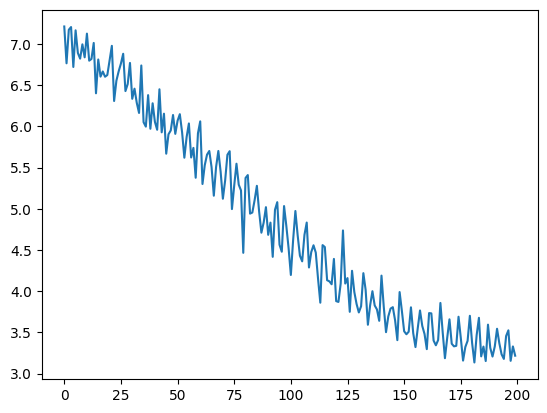

In [ ]:
plt.plot(np.array(trainer.state_pool.states)[:, :, 2].mean(axis=0))


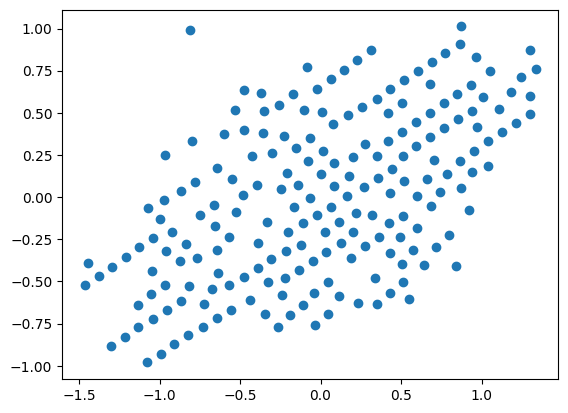

In [ ]:
xx, yy = trainer.state_pool.states[3][:,:2].T
plt.scatter(xx, yy)

In [ ]:
# load model
# steps = 125

# trainer = Trainer.load_model("model3.pt")
# rollout = trainer.rollout(steps = steps)

# to_display = []
# to_display.append(displayer.display_loss())
# # to_display.append(displayer.display_rollout_as_static(rollout))
# to_display.append(displayer.display_rollout_image(rollout))
# to_display.append(displayer.display_rollout_image_gauss(rollout))
# to_display.append(displayer.display_rollout_image_gauss_difference(rollout))
# # to_display.append(displayer.display_rollout_3d(rollout))

# display(displayer.display_multiple(to_display))


In [ ]:
x, y, a ,b = rollout[0].T

plt.scatter(x, y, s=20)

ValueError: too many values to unpack (expected 4)

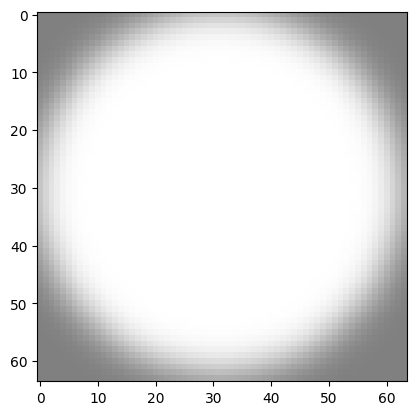

In [ ]:
plt.imshow(img_grid.cpu().numpy(), cmap='gray', alpha=0.5)

In [ ]:
# see all trainable parameters
for name, param in trainer.particle_system.named_parameters():
    if param.requires_grad:
        print(name,)

message_conv.nn.0.weight
message_conv.nn.0.bias
message_conv.nn.2.weight
message_conv.nn.2.bias
message_conv.lin.0.weight
message_conv.lin.0.bias
message_conv.lin.2.weight
message_conv.lin.2.bias
message_to_output_layer.weight
message_to_output_layer.bias
